In [8]:
import numpy as np
import matplotlib.pyplot as plt
import alg_CL
import alg_DH

In [9]:
# Badly Scaled System
def func(x):
    return np.array([
        1e6 * (x[0]**2 + x[1]**2 - 4.0), 
        1e-6 * (x[1] - x[0]**2 + 1.0)
    ])

def jac(x):
    return np.array([
        [2e6 * x[0], 2e6 * x[1]],
        [-2e-6 * x[0], 1e-6]
    ])

In [10]:
# Base test case: A simple nonlinear system
def func(x):
    return np.array([
        x[0]**2 + x[1]**2 - 4,
        x[1] - x[0]**2 + 1
    ])

def jac(x):
    return np.array([
        [2*x[0], 2*x[1]],
        [-2*x[0], 1]
    ])


In [11]:
# Error tolerance
XTOL = 1e-8
# Maximum number of iterations
MAX_ITER = 20
# Initial guess
x0 = np.array([1.5, 1.0])

In [12]:
# Deuflhard's local error-based Newton method
x, iter_list_DH, norm_err_list_DH = alg_DH.Newton(func, jac, x0, XTOL, MAX_ITER)

Converged at step 4
Solution: [1.51748991 1.30277564]


In [13]:
# Classical Newton method
x, iter_list_CL, norm_err_list_CL = alg_CL.Newton(func, jac, x0, XTOL, MAX_ITER)

Converged at step 4
Solution: [1.51748991 1.30277564]


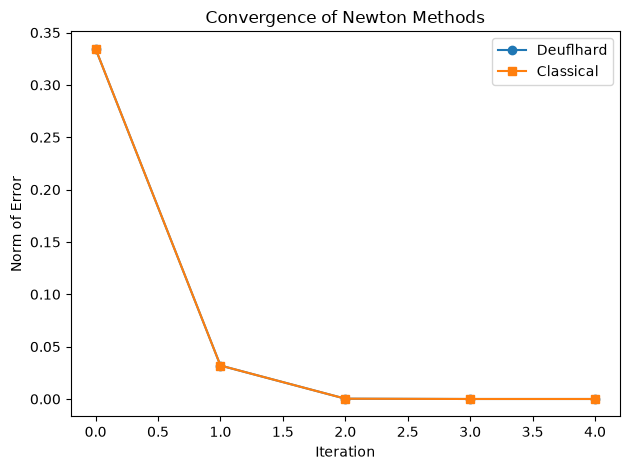

In [16]:
# Plotting convergence
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(iter_list_DH, norm_err_list_DH, marker='o', label='Deuflhard')
ax.plot(iter_list_CL, norm_err_list_CL, marker='s', label='Classical')
#ax.set_yscale('log')
#ax.set_xlim([0, MAX_ITER])
#ax.set_ylim([0, 1])
ax.set_xlabel('Iteration')
ax.set_ylabel('Norm of Error')
ax.set_title('Convergence of Newton Methods')
ax.legend()
plt.tight_layout()